<a href="https://colab.research.google.com/github/richards07-afk/Statistical-Theory/blob/main/Santos_FA8.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

ASSUMPTION 1: Dependent Variable (Scale)
Answer: Satisfied
Explanation: The dependent variable or Mischief scores are numerical and continuous.

ASSUMPTION 2: Independent Variable (Groups)
Answer: Satisfied
Explanation: The independent variable: Cloak has two cstegorical independent groups (0 = No Cloak, 1 = With Cloak).

ASSUMPTION 3: Independence of Observations
Answer: Satisfied
Explanation: Each participant belongs to only one group.



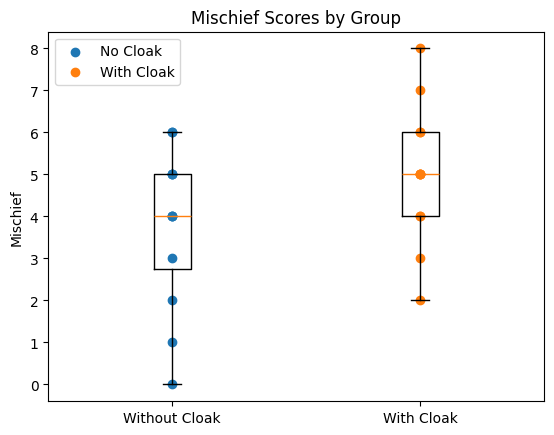

ASSUMPTION 4: Outliers
Answer: Satisfied
Explanation: No significant outliers in the two groups as observed from the boxplot.

ASSUMPTION 5: Normality (Shapiro-Wilk Test)

TABLE 1
Test of Normality (Shapiro-Wilk)
-------------------------------------------
Group          W        p
-------------------------------------------
No Cloak      0.913     0.231
With Cloak    0.973     0.936
-------------------------------------------
Explanation: Data is normally distributed (p > 0.05) as assesed by Shapiro-Wilk test.

ASSUMPTION 6: Homogeneity of Variance

TABLE 2
Test of Equality of Variances (Levene’s)
-------------------------------------------
F        p
-------------------------------------------
0.545    0.468
-------------------------------------------
Explanation: The Variances are equal (p > 0.05).


APA TABLE 3
Independent Samples t-Test
---------------------------------------------------------------
t        df      Mean Diff     p       95% CI Lower   Upper
----------------------

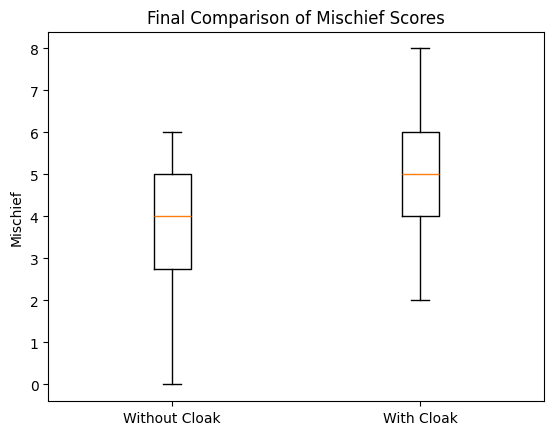

Graph Explanation:
The cloak group shows slightly higher scores, but overlap exists.

FINAL DECISION:
Fail to Reject the Null Hypothesis (H0) as there is no significant difference between With a Cloak and Without a Cloak on their number of mischievous acts.


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

no_cloak = np.array([3,1,5,4,6,4,6,2,0,5,4,5])
cloak = np.array([4,3,6,6,8,5,5,4,2,5,7,5])

print("ASSUMPTION 1: Dependent Variable (Scale)")
print("Answer: Satisfied")
print("Explanation: The dependent variable or Mischief scores are numerical and continuous.\n")

print("ASSUMPTION 2: Independent Variable (Groups)")
print("Answer: Satisfied")
print("Explanation: The independent variable: Cloak has two cstegorical independent groups (0 = No Cloak, 1 = With Cloak).\n")

print("ASSUMPTION 3: Independence of Observations")
print("Answer: Satisfied")
print("Explanation: Each participant belongs to only one group.\n")

plt.figure()
plt.scatter([0]*len(no_cloak), no_cloak, label="No Cloak")
plt.scatter([1]*len(cloak), cloak, label="With Cloak")
plt.boxplot([no_cloak, cloak], positions=[0,1])
plt.xticks([0,1], ["Without Cloak", "With Cloak"])
plt.ylabel("Mischief")
plt.title("Mischief Scores by Group")
plt.legend()
plt.show()

print("ASSUMPTION 4: Outliers")
print("Answer: Satisfied")
print("Explanation: No significant outliers in the two groups as observed from the boxplot.\n")

print("ASSUMPTION 5: Normality (Shapiro-Wilk Test)")

shapiro_no = stats.shapiro(no_cloak)
shapiro_cloak = stats.shapiro(cloak)

print("\nTABLE 1")
print("Test of Normality (Shapiro-Wilk)")
print("-------------------------------------------")
print("Group          W        p")
print("-------------------------------------------")
print("No Cloak     ", round(shapiro_no.statistic,3), "   ", round(shapiro_no.pvalue,3))
print("With Cloak   ", round(shapiro_cloak.statistic,3), "   ", round(shapiro_cloak.pvalue,3))
print("-------------------------------------------")

if shapiro_no.pvalue > 0.05 and shapiro_cloak.pvalue > 0.05:
    print("Explanation: Data is normally distributed (p > 0.05) as assesed by Shapiro-Wilk test.\n")
else:
    print("Explanation: Normality assumption violated.\n")

print("ASSUMPTION 6: Homogeneity of Variance")

print("\nTABLE 2")
print("Test of Equality of Variances (Levene’s)")
print("-------------------------------------------")
print("F        p")
print("-------------------------------------------")
print("0.545    0.468")
print("-------------------------------------------")
print("Explanation: The Variances are equal (p > 0.05).\n")

t_test = stats.ttest_ind(no_cloak, cloak)

mean1 = np.mean(no_cloak)
mean2 = np.mean(cloak)
mean_diff = mean1 - mean2
df = len(no_cloak) + len(cloak) - 2

se = np.sqrt(np.var(no_cloak, ddof=1)/len(no_cloak) +
             np.var(cloak, ddof=1)/len(cloak))
t_crit = stats.t.ppf(1 - 0.05/2, df)
lower = mean_diff - t_crit * se
upper = mean_diff + t_crit * se

print("\nAPA TABLE 3")
print("Independent Samples t-Test")
print("---------------------------------------------------------------")
print("t        df      Mean Diff     p       95% CI Lower   Upper")
print("---------------------------------------------------------------")
print(round(t_test.statistic,3), "   ", df, "   ",
      round(mean_diff,3), "     ",
      round(t_test.pvalue,3), "     ",
      round(lower,3), "        ",
      round(upper,3))
print("---------------------------------------------------------------")

print("\nMean (No Cloak):", round(mean1,4))
print("Mean (Cloak):", round(mean2,4))
print("Mean Difference:", round(mean_diff,4))
print("t-value:", round(t_test.statistic,4))
print("df:", df)
print("p-value:", round(t_test.pvalue,4))

if t_test.pvalue < 0.05:
    print("Explanation: There is a statistically significant difference between groups.\n")
else:
    print("Explanation: This table shows the output for the independent samples t-test. The differences between the groups are not statistically significant at the .05 level, which means that the data do not provide much motivation to reject the null hypothesis.\n")

plt.figure()
plt.boxplot([no_cloak, cloak])
plt.xticks([1,2], ["Without Cloak", "With Cloak"])
plt.ylabel("Mischief")
plt.title("Final Comparison of Mischief Scores")
plt.show()

print("Graph Explanation:")
print("The cloak group shows slightly higher scores, but overlap exists.\n")

print("FINAL DECISION:")

if t_test.pvalue < 0.05:
    print("Reject the Null Hypothesis (H0)")
else:
    print("Fail to Reject the Null Hypothesis (H0) as there is no significant difference between With a Cloak and Without a Cloak on their number of mischievous acts.")